In [5]:
from glob import glob

import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torch.optim import Adam, SGD
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchsummary import summary
import cv2

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [162]:
class KaiDataset(Dataset):
    def __init__(self, path='data/best_pictures', transform=None):
        self.data, self.labels = sorted(glob(f'{path}/*.png')), sorted(glob(f'{path}/*.txt'))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        f = self.data[idx]
        target_f = self.labels[idx]
        target = torch.tensor(np.loadtxt(target_f, delimiter=' '))
        im = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        im = torch.tensor(im).view(1, 64, 64)
        # im = im.permute(2, 0, 1)
        return im.float().to(device), target.float().flatten().to(device)

In [ ]:
data = KaiDataset()
im, label = data[4]

In [164]:
print(im.shape)

torch.Size([1, 64, 64])


tensor([ 142.5625,  155.9570,  163.9062,  ..., -232.5547, -243.3164,
        -237.9219], device='cuda:0')


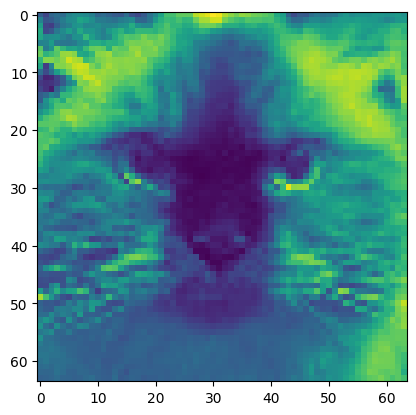

In [165]:
plt.imshow(im.permute(1, 2, 0).cpu())
print(label)

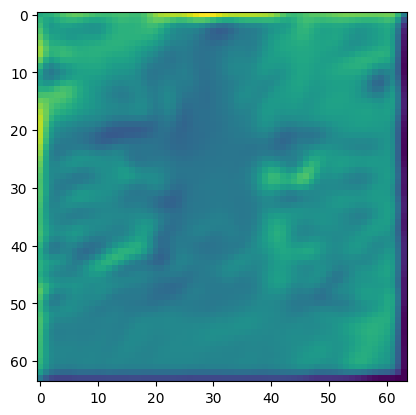

In [166]:
plt.imshow(label.reshape(1, 64, 64).permute(1, 2, 0).cpu())

In [167]:
algos = pd.read_csv("data/algos.csv", header=None)
algos

,0,1,2,3,4,5,6,7,8
0,-1.0000,-0.5000,0.0000,-0.5000,0.5000,0.5000,0.0000,0.5000,1.0000
1,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625


In [168]:
f1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1).to(device)
f1.weight.data = torch.tensor(algos.iloc[0].values.reshape(1, 1, 3, 3)).float().to(device)
f1.weight.data

tensor([[[[-1.0000, -0.5000,  0.0000],
          [-0.5000,  0.5000,  0.5000],
          [ 0.0000,  0.5000,  1.0000]]]], device='cuda:0')

In [134]:
f1_im = f1(im)
print(f1_im.shape)
f1_im

torch.Size([1, 64, 64])


tensor([[[ 411.2733,  298.2733,  279.2733,  ...,  332.7733,  329.7733,
            88.2733],
         [ 347.2733,   75.2733,   70.2733,  ...,   78.7733,   85.7733,
          -162.7267],
         [ 373.7733,  104.2733,   69.7733,  ...,   89.2733,   88.7733,
          -167.7267],
         ...,
         [ 212.7733,   77.2733,   74.7733,  ...,   65.7733,   52.7733,
           -62.2267],
         [ 219.2733,   91.2733,   62.7733,  ...,  120.2733,  102.7733,
           -40.7267],
         [  52.7733,  -94.2267, -134.7267,  ...,  -40.7267,  -77.2267,
          -125.7267]]], device='cuda:0', grad_fn=<SqueezeBackward1>)

In [169]:
f2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1).to(device)
f2.weight.data = torch.tensor(algos.iloc[1].values.reshape(1, 1, 3, 3)).float().to(device)
f2.weight.data

tensor([[[[0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625],
          [0.0625, 0.0625, 0.0625]]]], device='cuda:0')

In [136]:
f2_im = f2(im)
print(f2_im.shape)
f2_im

torch.Size([1, 64, 64])


tensor([[[41.1525, 59.5900, 55.0900,  ..., 63.2775, 62.7775, 41.5275],
         [63.4025, 92.0275, 85.4650,  ..., 95.9650, 94.9025, 62.8400],
         [66.3400, 97.4650, 91.7775,  ..., 96.9650, 95.6525, 63.4025],
         ...,
         [38.4650, 59.6525, 63.9025,  ..., 34.2775, 36.4025, 24.8400],
         [37.9025, 59.0900, 61.2150,  ..., 39.8400, 41.5900, 27.8400],
         [26.2150, 40.5275, 41.7150,  ..., 30.4650, 32.0900, 21.0900]]],
       device='cuda:0', grad_fn=<SqueezeBackward1>)

In [170]:
f3 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1).to(device)
f3.weight.data

tensor([[[[ 0.0283,  0.2020, -0.2984],
          [-0.0187,  0.0968,  0.2241],
          [ 0.0327, -0.2091,  0.3194]]]], device='cuda:0')

In [171]:
import itertools
from copy import deepcopy

layer_map = {
    1: f1,
    2: f2,
    3: f3
}

models = []

combinations = itertools.permutations([1, 2, 3])
for comb in combinations:
    layer1, layer2, layer3 = [layer_map[i] for i in comb]
    layers = [layer1, layer2, layer3]
    for i, j in enumerate(comb):
        if j in [1, 2]:
            for _, param in layers[i]._parameters.items(): 
                param.requires_grad = False
    model = nn.Sequential(
        deepcopy(layer1),
        deepcopy(layer2),
        deepcopy(layer3),
        nn.Flatten()
    )
    models.append(model)
models

[Sequential(
   (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Flatten(start_dim=1, end_dim=-1)
 ),
 Sequential(
   (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Flatten(start_dim=1, end_dim=-1)
 ),
 Sequential(
   (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Flatten(start_dim=1, end_dim=-1)
 ),
 Sequential(
   (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(1, 1, 

In [189]:
def get_model(i: int):
    model = models[i].to(device)

    loss_fn = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=1e-4)
    
    return model, loss_fn, optimizer

In [173]:
def train_batch(x, y, model, opt, loss_fn):
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

In [174]:
def get_data():     
    train = KaiDataset()     
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

In [175]:
trn_dl = get_data()

In [93]:
model, loss_fn, optimizer = get_model(1)

In [94]:
summary(model, (1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 1, 64, 64]              10
            Conv2d-2            [-1, 1, 64, 64]              10
            Conv2d-3            [-1, 1, 64, 64]              10
           Flatten-4                 [-1, 4096]               0
Total params: 30
Trainable params: 10
Non-trainable params: 20
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.12
Params size (MB): 0.00
Estimated Total Size (MB): 0.14
----------------------------------------------------------------


In [190]:
n_epoch = 200

train_losses, train_accuracies = {i: [] for i in [3, 5]}, {i: [] for i in [3, 5]}
for epoch in range(n_epoch):
    print(epoch)
    for i in [3, 5]:
        print(f"Model: {i}")
        model, loss_fn, optimizer = get_model(i)
        train_epoch_losses, val_epoch_losses = [], []
        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)        
        train_epoch_loss = np.array(train_epoch_losses).mean()

        print(train_epoch_loss)
        train_losses[i].append(train_epoch_loss)

0
Model: 3
0.012897552573122084
Model: 5
0.020416887069586664
1
Model: 3
0.01303824337082915
Model: 5
0.020099710789509118
2
Model: 3
0.01296049915254116
Model: 5
0.020182685111649334
3
Model: 3
0.0128910934436135
Model: 5
0.020160405663773417
4
Model: 3
0.013008997746510431
Model: 5
0.02016393165104091
5
Model: 3
0.01296571915736422
Model: 5
0.020223488041665405
6
Model: 3
0.013030579226324335
Model: 5
0.02019310148898512
7
Model: 3
0.012999408936593682
Model: 5
0.020097672706469893
8
Model: 3
0.013011312374146655
Model: 5
0.020211043884046376
9
Model: 3
0.012959504674654454
Model: 5
0.020149553834926337
10
Model: 3
0.013032571150688455
Model: 5
0.02012498542899266
11
Model: 3
0.012936791288666427
Model: 5
0.020186012261547148
12
Model: 3
0.013008062960579991
Model: 5
0.020194613840430975
13
Model: 3
0.013023641979089007
Model: 5
0.020162398752290756
14
Model: 3
0.012986714515136555
Model: 5
0.020131052937358618
15
Model: 3
0.013002086721826345
Model: 5
0.020203653431963176
16
Model: 

In [177]:
models[3][1].weight

Parameter containing:
tensor([[[[0.1305, 0.2440, 0.1292],
          [0.2436, 0.5040, 0.2464],
          [0.1293, 0.2464, 0.1263]]]], device='cuda:0', requires_grad=True)

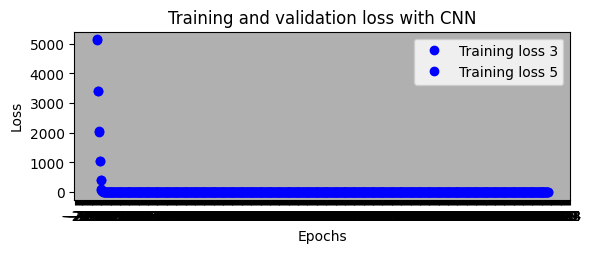

In [179]:
epochs = np.arange(n_epoch)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.subplot(211)
for i in [3, 5]:
    plt.plot(epochs, train_losses[i], 'bo', label=f'Training loss {i}')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with CNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()

In [180]:
m = models[3].eval()
f1_im = m(im)
print(f1_im.shape)
f1_im = f1_im.resize(1, 64, 64).detach().cpu()

torch.Size([1, 4096])


/root/Desktop/vision/ml-course/.venv/lib/python3.12/site-packages/torch/_tensor.py:1000: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


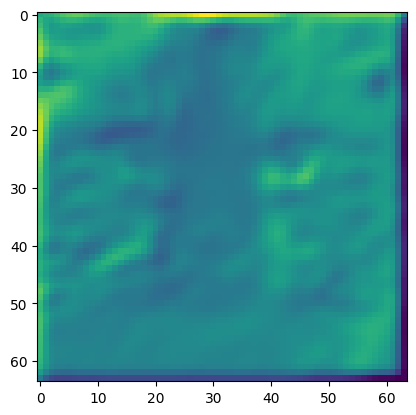

In [181]:
plt.imshow(f1_im.permute(1, 2, 0).cpu())

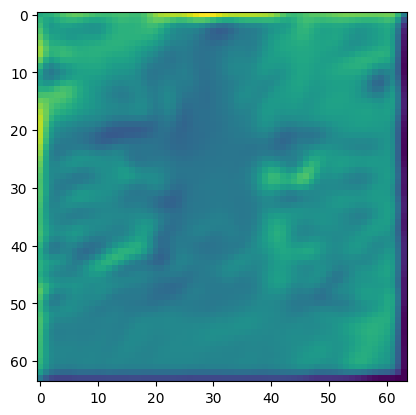

In [182]:
l = label.resize(1, 64, 64).detach().cpu()
plt.imshow(l.permute(1, 2, 0).cpu())

In [1]:
import pandas as pd

In [ ]:
ans = pd.DataFrame([[0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625],
                    [0.1300,0.2450,0.1300,0.2450,0.5050,0.2450,0.1300,0.2450,0.1300],
                    [-1.0000,-0.5000,0.0000,-0.5000,0.5000,0.5000,0.0000,0.5000,1.0000]])
ans

,0,1,2,3,4,5,6,7,8
0,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625
1,0.1300,0.2500,0.1300,0.2500,0.5000,0.2500,0.1300,0.2500,0.1300
2,-1.0000,-0.5000,0.0000,-0.5000,0.5000,0.5000,0.0000,0.5000,1.0000


In [185]:
ans.to_csv("results/reconstructed_algos.csv", header='', index=False)